# Acoustic Scattering for head shaped obstacle

This notebook provide acoustic field simulation for scattering field using an head shaped obstacle.

Due to computing constrained with provided trained networks for single direction of incident wave.


## Google Colab setup

In [94]:
# Export the modules
#!git clone https://github.com/Dankradino/Acoustic-Scattering-PINN.git

import os
os.getcwd()
#os.chdir('/content/Acoustic-Scattering-PINN/')
os.chdir('/home/dankrad/Desktop/code/Acoustic-Scattering-PINN/')
os.getcwd()

'/home/dankrad/Desktop/code/Acoustic-Scattering-PINN'

In [95]:
#!pip install trimesh pysofaconventions==0.1.5 rtree  # Sufficient for testing models

## Import and configuration setup

In [96]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from model import init_model_from_conf, init_conditioned_model
from model.phisk_loader import load_directional_model
from model.lora_interp_loader import load_interpolated_model
from shape import generate_circle
from eval import evaluate_circle_estimation, evaluate_circle_estimation_direction, sound_hard_circle
from eval import evaluate_hrtf
import yaml
from utils import load_hrtf_config, generate_grid
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon


from shape import  generate_sphere, get_sphere_param
from Trainer import Trainer3D
from utils import create_3d_mesh_mask
from Dataloader import load_hrtf
import trimesh
from eval import evaluate_sphere_estimation


torch.manual_seed(30)

In [ ]:
#Load file

# Example 
dir = 'checkpoints/hrtf/p2_x_with_ear'          
model_name = 'rff'                                       # Name of model used
config_filename = f'{dir}/config.yaml'
model_filename = f'{dir}/{model_name}.pth'  #Filename of the model weights
subject_id = 'P0002'
#mesh_path = f'SONICOM/{subject_id}/3DSCAN/{subject_id}_wtt_prepd.stl'
sofa_path = f'SONICOM/{subject_id}/SYNTHETIC_HRTF/HRIR_SONICOM_44100.sofa'
#normalize_path = f'SONICOM/{subject_id}/3DSCAN/{subject_id}_normalize.stl'

mesh_path = f'SONICOM/{subject_id}/3DSCAN/{subject_id}_normalize.stl'

loss_fn = nn.MSELoss()

config, DTYPE = load_hrtf_config(config_filename)
device = config['device']
config['model'] = model_name

print(config)
print(config['direction'])
# Note we provide another model trained for direction [1.,0.,0.] that you can test by just replacing
# ref_filename = f'checkpoints/{dim}/scattering/{model_name}.pth'
# and config['direction'] = torch.tensor([[1.], [0.], [0.]], device='cuda:0')

{'L': 1, 'adam': {'batch_boundary': 8192, 'batch_size': 8192, 'epochs': 50000, 'gamma': 0.5, 'keeping_time': 25, 'lr': 0.0001, 'n_scheduler': 15000, 'num_workers': 0}, 'celerity': 343, 'custom_shape': True, 'device': device(type='cuda', index=0), 'direction': tensor([[0.],
        [1.],
        [0.]], device='cuda:0'), 'fine': {'batch_boundary': 16384, 'batch_size': 32768, 'epochs': 300, 'gamma': 0.2, 'keeping_time': 2, 'lr': 0.1, 'max_iter': 25, 'n_scheduler': 500, 'num_workers': 0}, 'first_omega': 10.0, 'frequency': tensor(300., device='cuda:0'), 'hidden_dim': 512, 'hidden_omega': 30.0, 'hrtf': True, 'id': 'cfg_6b346ab127', 'input_dim': 3, 'model': 'rff', 'mu': 1.0, 'num_layers': 3, 'output_dim': 2, 'p0': 10, 'pml_dampling': 5, 'pml_size': 0.25, 'preload': False, 'res': 128, 'rff': 512, 'scale': 5.475182350824548, 'sigma': 0.1, 'sigma_fourier': 1.0, 'source': tensor([[0.0000, 8.2128, 0.0000]], device='cuda:0'), 'DTYPE': torch.float32}
tensor([[0.],
        [1.],
        [0.]], device

## Loading HRTF mesh and sofa file

In [98]:
#Load head mesh
mesh =  trimesh.load(mesh_path, process=False)
boundary = mesh.vertices
normals = mesh.vertex_normals

# Load associated sofa file
sofa = load_hrtf(sofa_path, boundary, DTYPE, device)
idx_ear = sofa["ear_idx"].cpu().numpy()  # removal of ears canal entrance in boundary conditions

# Head visualisation — two viewpoints to ensure both ear canal entrances are always visible
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

ear_pts = boundary[idx_ear]  # shape (2, 3); ears are aligned on Y axis
left_idx  = np.argmin(ear_pts[:, 1])   # more negative Y → left ear
right_idx = np.argmax(ear_pts[:, 1])   # more positive Y → right ear

scale  = mesh.vertices.max(axis=0) - mesh.vertices.min(axis=0)
center = mesh.vertices.mean(axis=0)
half   = scale.max() / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': '3d'})
for ax, (elev, azim), title in zip(axes, [(15, -70), (15, 110)], ['Left-ear view', 'Right-ear view']):
    verts = mesh.vertices[mesh.faces]
    poly = Poly3DCollection(verts, alpha=0.15, facecolor='lightblue', edgecolor='none')
    ax.add_collection3d(poly)

    ax.scatter(*ear_pts[left_idx],  c='red',   s=80, depthshade=False, zorder=10, label='Left ear')
    ax.scatter(*ear_pts[right_idx], c='green', s=80, depthshade=False, zorder=10, label='Right ear')

    ax.set_xlim(center[0] - half, center[0] + half)
    ax.set_ylim(center[1] - half, center[1] + half)
    ax.set_zlim(center[2] - half, center[2] + half)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    ax.legend(loc='upper left')

fig.suptitle(f'Head mesh – {subject_id}', fontsize=14)
plt.tight_layout()
plt.show()


Vertices corresponding to ears:
Vertex 1: [0.00206318 0.35485461 0.01309593]
Vertex 2: [-0.01343384 -0.39411208 -0.00793125]
First frequencies available : [0.0 150.0 300.0 450.0 600.0 750.0 900.0 1050.0 1200.0 1350.0 1500.0
 1650.0 1800.0 1950.0 2100.0]


KeyboardInterrupt: 

## Loading the model



In [ ]:
# Loading and evaluating reference model

reference_model = init_model_from_conf(config).to(device)
print('Loading weights for reference model')
reference_model.load_state_dict(torch.load(model_filename))
print('Reference model loaded!')

mask = np.ones(len(boundary), dtype=bool)
mask[idx_ear] = False

# Apply mask
# boundary = boundary[mask]
# normals = normals[mask]

Loading weights for reference model
Reference model loaded!


In [ ]:
res = 64
L = config['L']
grid = generate_grid(L, res, 3, device=device)
grid_np = grid.cpu().numpy()

# --- Head interior mask via trimesh ---
inside = mesh.contains(grid_np)           # (N,) bool, True = inside head
inside_3d = inside.reshape(res, res, res)
outside_t = torch.tensor(~inside, device=device)

# --- Scattered field (model output) ---
with torch.no_grad():
    reference_model.eval()
    p_s = torch.zeros(grid_np.shape[0], 2, device=device)
    p_s[outside_t] = reference_model(grid[outside_t])

# --- Incident wave ---
freq  = float(config['frequency'])
scale = float(config.get('scale', 1.0))
p0    = float(config.get('p0', 1.0))
k     = 2 * np.pi * freq / config['celerity']
mode  = config.get('mode', 'plane')

if mode == 'source':
    x_source = config['source'].reshape(1, 3).float()   # (1, 3)
    r = torch.linalg.norm(grid.float() - x_source, dim=1) / scale   # (N,)
    r = torch.clamp(r, min=1e-6)
    u_inc_c = p0 * torch.exp(torch.tensor(1j * k, dtype=torch.complex64) * r) / (4 * np.pi * r)
else:
    direction = config['direction'].squeeze().float()
    r_proj = (grid.float() @ direction) / scale
    u_inc_c = torch.exp(torch.tensor(1j * k, dtype=torch.complex64) * r_proj)

p_inc = torch.stack([u_inc_c.real, u_inc_c.imag], dim=1)
p_inc[~outside_t] = 0.0    # zero inside head

# --- Total field ---
p_total = p_s + p_inc


In [ ]:
def compute_xy_magnitude(p, res, inside_3d, axis='z'):
    """Return masked scattered-field magnitude at the XY mid-plane (z=0)."""
    z_mid = res // 2
    if axis == 'x':
        shape = (z_mid, slice(None), slice(None))
    elif axis == 'y':
        shape = (slice(None), z_mid, slice(None))
    elif axis == 'z':
        shape = (slice(None), slice(None), z_mid)

    p_np = p.cpu().numpy()
    p_r = p_np[:, 0].reshape(res, res, res)[shape]
    p_i = p_np[:, 1].reshape(res, res, res)[shape]
    mag = np.sqrt(p_r**2 + p_i**2)
    return np.ma.masked_where(inside_3d[shape], mag)

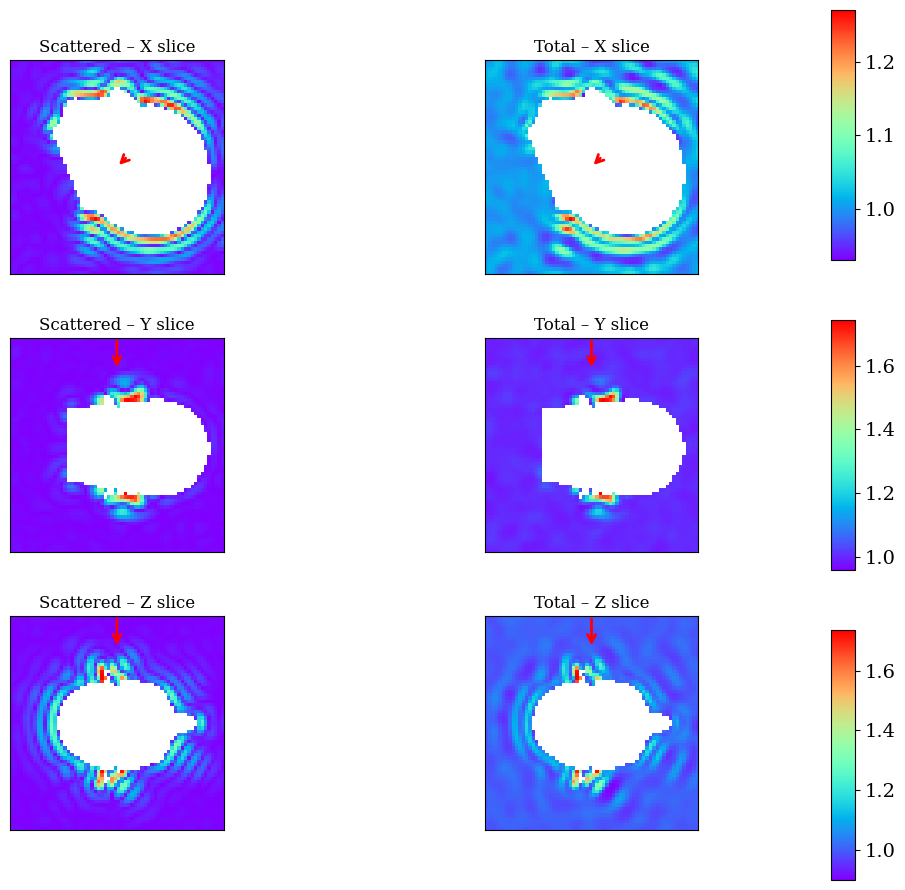

In [ ]:
axes_labels = ['x', 'y', 'z']
p_list = [p_s, p_total]
p_names = ['Scattered', 'Total']

arrow_coords = {
    'z': dict(xy=(0., 0.7 * L), xytext=(0., L)),   # points along Y
    'y': dict(xy=(0., 0.7 * L), xytext=(0., L)),    # points along Z (horizontal in XZ)
    'x': dict(xy=(0., 0.), xytext=(0.1 , 0.1)),    # points along X
}


plt.rcParams.update({'text.usetex': False, 'font.family': 'serif',
                     'font.size': 14, 'axes.titlesize': 12, 'axes.labelsize': 14})
cmap = 'rainbow'
fig, axs = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=False)
plt.subplots_adjust(right=0.88, hspace=0.3, wspace=0.1)

im_grid = {}  # store one imshow handle per row for colorbars

for i, axe in enumerate(axes_labels):
    for j, (pf, pname) in enumerate(zip(p_list, p_names)):
        u = compute_xy_magnitude(pf, res, inside_3d, axe)

        im = axs[i][j].imshow(u, extent=[-L, L, -L, L],
                               origin='lower', cmap=cmap,
                               vmin=u.min(), vmax=u.max())
        im_grid[(i, j)] = im

        # Arrow pointing along the incident direction (x-axis)
        axs[i][j].annotate('', arrowprops=dict(arrowstyle='->', color='red', lw=2),
                        **arrow_coords[axe])


        axs[i][j].set_title(f'{pname} – {axe.upper()} slice')
        axs[i][j].set_xticks([])
        axs[i][j].set_yticks([])

# One colorbar per row, placed to the right
for i in range(3):
    cbar_ax = fig.add_axes([0.90, 0.68 - i * 0.31, 0.02, 0.25])
    fig.colorbar(im_grid[(i, 1)], cax=cbar_ax)  # last column is now index 1

plt.show()

In [ ]:
boundary = torch.tensor(mesh.vertices, device=device)
z_tolerance = 0.01  # adjust as needed
idx_z = torch.abs(boundary[:, 2]) < z_tolerance
# Filter for points near z=0 AND positive x
idx_combined = idx_z & (boundary[:, 0] > 0)
boundary_filtered = boundary[idx_combined]

# Sort by y-coordinate
sorted_indices = torch.argsort(boundary_filtered[:, 1])
boundary = boundary_filtered[sorted_indices]
id_use = torch.linspace(0, boundary.shape[0] - 1, boundary.shape[0]).int()
boundary_no_ear = boundary[id_use]

def inc_wave(coords, config, batch_size=100_000):
    """
    Compute incident wave in memory-efficient batches.

    Args:
        coords: [N, 2] tensor of observation points
        batch_size: max number of points per batch

    Returns:
        [N, 2] tensor with real and imaginary parts of incident field
    """
    N = coords.shape[0]
    output = []

    for i in range(0, N, batch_size):
        batch_coords = coords[i:i+batch_size]
        r = batch_coords @ config['direction']
        g = torch.exp(1j * 2 * np.pi * config['frequency'] / config['celerity'] * r)
        batch_output = torch.stack((g.real, g.imag), dim=-1)
        output.append(batch_output)

    return torch.cat(output, dim=0).squeeze(1)
def model_evaluation(model, config, coords, batch_size=100_000):
    """
    Replace this with your actual model inference

    Args:
        coords: numpy array of shape (N, 3) with x, y, z coordinates

    Returns:
        numpy array of shape (N, 2) with [real, imaginary] pressure values
    """

    coords = torch.tensor(coords, device=device, dtype=DTYPE)
    N = coords.shape[0]
    results = []

    for i in range(0, N, batch_size):
        batch_coords = coords[i:i+batch_size]  # shape [B, 3]

        with torch.no_grad():
            model_out = model(batch_coords)     # shape [B, 2]
            inc_out = inc_wave(batch_coords, config)    # shape [B, 2]

            if model_out.shape != inc_out.shape:
                raise ValueError(f"Shape mismatch: model {model_out.shape}, inc {inc_out.shape} at batch {i}")

            res = model_out + inc_out           # shape [B, 2]
            results.append(res.detach().cpu())

    return torch.cat(results, dim=0).numpy()

def mag_phase_decomp(model, config, boundary):
    print('direction',config['direction'])
    p = model_evaluation(model, config, boundary)
    p_complex = p[:, 0] + 1j * p[:, 1]
    p_complex = p_complex
    boundary = boundary.cpu().numpy()
    arg_p = np.angle(p_complex)
    arg_p = np.unwrap(arg_p)
    mag_p = np.abs(p_complex)
    return mag_p, arg_p

config1_no_ear['direction'] = torch.tensor([1., 0., 0.], device = 'cuda:0')
mag_p1_no_ear, arg_p1_no_ear = mag_phase_decomp(model1_no_ear, config1_no_ear, boundary_no_ear)

mag_p2_no_ear, arg_p2_no_ear = mag_phase_decomp(model2_no_ear, config2, boundary_no_ear)
import matplotlib.pyplot as plt
# Create figure with 2 subplots (1 row, 2 columns)

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.titlesize'] = 24  # Title font size
plt.rcParams['axes.labelsize'] = 20  # Axis label font size
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(16, 6))

# Get y-coordinates for x-axis
y_coords_no_ear = boundary_no_ear[:, 1] / config1['scale']
y_coords_no_ear = y_coords_no_ear.cpu().numpy()
# Left subplot: Model 1 with dual y-axes
color_mag = 'tab:red'
ax1.set_xlabel('y-coordinate (m)', fontsize=12)
ax1.set_ylabel('Magnitude', color=color_mag, fontsize=12)
ax1.plot(y_coords_no_ear, mag_p1_no_ear, color=color_mag, linewidth=2, label='Magnitude')
ax1.tick_params(axis='y', labelcolor=color_mag)
ax1.set_title(r'Full field evolution around the head with no ears for $\mathbf{d} = (1,0,0)$', fontsize=14, fontweight='bold')

# Create second y-axis for phase
ax2 = ax1.twinx()
color_phase = 'tab:blue'
ax2.set_ylabel('Phase (radians)', color=color_phase, fontsize=12)
ax2.plot(y_coords_no_ear, arg_p1_no_ear, color=color_phase, linewidth=2, label='Phase')
ax2.tick_params(axis='y', labelcolor=color_phase)

# Right subplot: Model 2 with dual y-axes
color_mag = 'tab:red'
ax3.set_xlabel('y-coordinate (m)', fontsize=12)
ax3.set_ylabel('Magnitude', color=color_mag, fontsize=12)
ax3.plot(y_coords_no_ear, mag_p2_no_ear, color=color_mag, linewidth=2, label='Magnitude')
ax3.tick_params(axis='y', labelcolor=color_mag)
ax3.set_title(r'Full field evolution around the head with no ears for $\mathbf{d} = (0,1,0)$', fontsize=14, fontweight='bold')

# Create second y-axis for phase
ax4 = ax3.twinx()
color_phase = 'tab:blue'
ax4.set_ylabel('Phase (radians)', color=color_phase, fontsize=12)
ax4.plot(y_coords_no_ear, arg_p2_no_ear, color=color_phase, linewidth=2, label='Phase')
ax4.tick_params(axis='y', labelcolor=color_phase)

fig.tight_layout()
plt.savefig("hrtf_direction_comparison.pdf", format='pdf', bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints/hrtf/cfg_fcdde617aa/config.yaml'